# 02 · The Knowability Trichotomy (live, 123-task suite)

Frozen `f0`=best-val detector; candidate `f_a`=rank-normalised logistic stack; benefit
`B=AUROC(f_a)-AUROC(f0)` (oracle). Decision from **label-free** evidence `Z` via a leave-one-out
estimator + conformal radius `ε`. KGA abstains where the benefit is near zero.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); TV=os.path.join(REPO,'experiments','kbound','theory_validation')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)
from scipy.stats import ks_2samp, rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import roc_auc_score

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


In [2]:
def rn(S):
    R=np.empty_like(S,dtype=float)
    for j in range(S.shape[1]): R[:,j]=(rankdata(S[:,j])-1)/(len(S)-1)
    return R
def auc(y,s): return roc_auc_score(y,s) if len(np.unique(y))>1 else np.nan
rows=[]
for f in sorted(glob.glob(ARCH+'/*.npz')):
    d=np.load(f,allow_pickle=True); Sv,yv,St,yt,va=d['Sval'],d['yval'],d['Stest'],d['ytest'],d['val_auc']
    if len(np.unique(yt))<2: continue
    j0=int(np.argmax(va)); a0=auc(yt,St[:,j0])
    clf=LogisticRegression(max_iter=1000).fit(rn(Sv),yv); aa=auc(yt,clf.predict_proba(rn(St))[:,1])
    ks=[ks_2samp(Sv[:,k],St[:,k]).statistic for k in range(Sv.shape[1])]
    Rt=rn(St); C=np.corrcoef(Rt.T); iu=np.triu_indices_from(C,k=1); vs=np.sort(va)[::-1]
    rows.append(([float(vs[0]),float(vs[0]-vs[1]),float(np.mean(va)),float(np.mean(ks)),float(np.max(ks)),float(1-np.nanmean(C[iu])),float(np.std(va)),float(np.mean(yv)),float(np.log(len(yt)))],float(aa-a0)))
X=np.array([r[0] for r in rows]); B=np.array([r[1] for r in rows]); N=len(B); Bh=np.zeros(N)
for i in range(N):
    tr=np.arange(N)!=i; m=GradientBoostingRegressor(n_estimators=200,max_depth=2,learning_rate=0.05,subsample=0.8,random_state=0).fit(X[tr],B[tr]); Bh[i]=m.predict(X[i:i+1])[0]
eps=float(np.quantile(np.abs(Bh-B),0.9)); dec=np.where(Bh-eps>0,'ADAPT',np.where(Bh+eps<0,'FREEZE','ABSTAIN')); ad=dec=='ADAPT'
print('decisions:',{k:int((dec==k).sum()) for k in ['ADAPT','FREEZE','ABSTAIN']})
print('adapt precision (B>0|ADAPT) = %.3f'%np.mean(B[ad]>0))
print('abstain mean|B| %.3f  vs acted mean|B| %.3f'%(np.mean(np.abs(B[dec=='ABSTAIN'])),np.mean(np.abs(B[dec!='ABSTAIN']))))

decisions: {'ADAPT': 9, 'FREEZE': 0, 'ABSTAIN': 114}
adapt precision (B>0|ADAPT) = 0.778
abstain mean|B| 0.031  vs acted mean|B| 0.160


## Certificate & safety figures


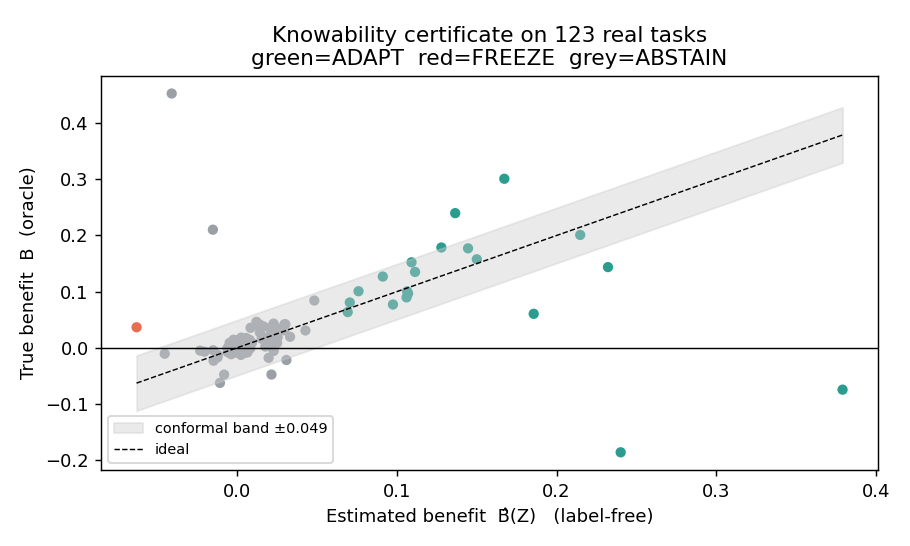

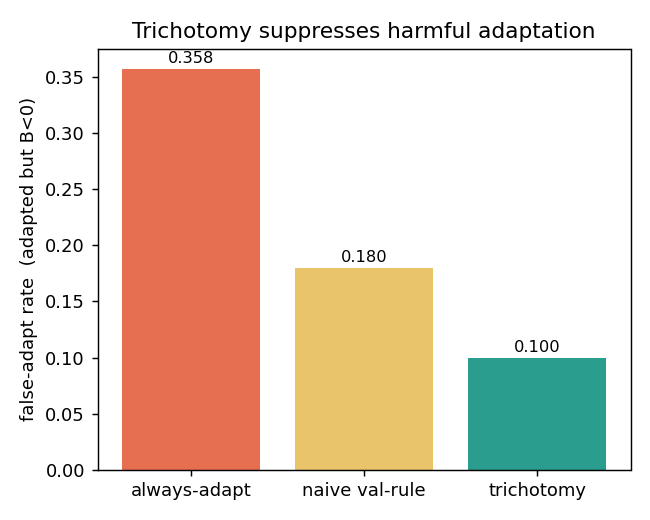

In [3]:
fig('fig_certificate.png'); fig('fig_false_adapt.png')

## Ablations: which evidence feature matters, and the α–coverage tradeoff


evidence-drop regret (higher = more important):
  disagree         0.094
  val_mean         0.043
  log_ntest        0.039
  ks_max           0.037
  val_gap          0.037

alpha sweep:
  alpha 0.01 {'eps': 0.3239879866559746, 'coverage': 0.11382113821138211, 'false_adapt': 0.0}
  alpha 0.05 {'eps': 0.1912347925016284, 'coverage': 0.26287262872628725, 'false_adapt': 0.07368421052631578}
  alpha 0.1 {'eps': 0.13907528498158234, 'coverage': 0.34959349593495936, 'false_adapt': 0.06504065040650407}
  alpha 0.2 {'eps': 0.09104740192177388, 'coverage': 0.4878048780487805, 'false_adapt': 0.07228915662650602}


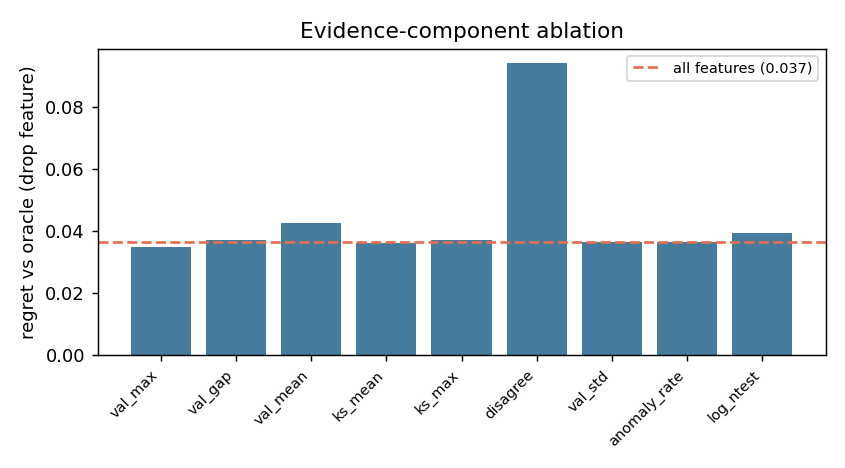

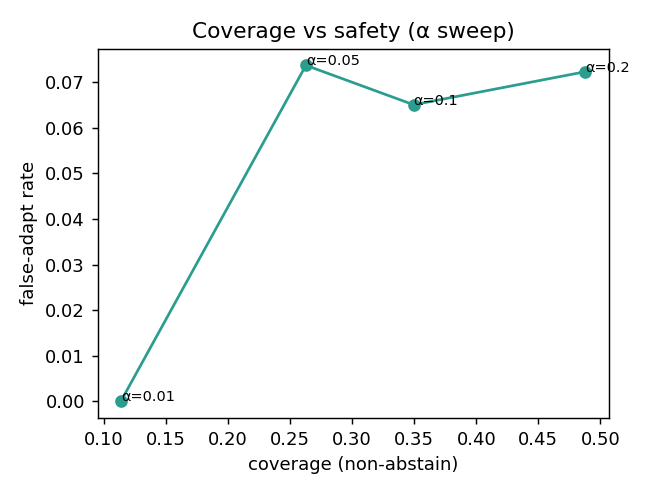

In [4]:
a=jload('ablations.json')
print('evidence-drop regret (higher = more important):')
for k,v in sorted(a.get('evidence_drop',{}).items(), key=lambda x:-x[1]['regret'])[:5]: print('  %-16s %.3f'%(k,v['regret']))
print('\nalpha sweep:'); [print('  alpha',k,v) for k,v in a.get('alpha_sweep',{}).items()]
fig('fig_ablation_evidence.png'); fig('fig_alpha_coverage.png')